In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv("/content/SO2_daily_aqs_data_downloaded_2026-09-17 19_15_24.csv")
df.head()

,Date,Site ID,POC,Daily Max SO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2025-01-01,20900034,1,9.1,Parts per billion,13,NCORE,24,100,42401,...,132,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Alaska Department Of Environmental Conservation,POPULATION EXPOSURE,NaN,NCORE,3,NaN
1,2025-01-02,20900034,1,10.8,Parts per billion,14,NCORE,24,100,42401,...,132,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Alaska Department Of Environmental Conservation,POPULATION EXPOSURE,NaN,NCORE,3,NaN
2,2025-01-03,20900034,1,14.6,Parts per billion,20,NCORE,23,96,42401,...,132,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Alaska Department Of Environmental Conservation,POPULATION EXPOSURE,NaN,NCORE,3,NaN
3,2025-01-04,20900034,1,11.1,Parts per billion,16,NCORE,24,100,42401,...,132,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Alaska Department Of Environmental Conservation,POPULATION EXPOSURE,NaN,NCORE,3,NaN
4,2025-01-05,20900034,1,8.4,Parts per billion,11,NCORE,24,100,42401,...,132,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Alaska Department Of Environmental Conservation,POPULATION EXPOSURE,NaN,NCORE,3,NaN


In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          728 non-null    object 
 1   Site ID                       728 non-null    int64  
 2   POC                           728 non-null    int64  
 3   Daily Max SO2 Concentration   728 non-null    float64
 4   Units                         728 non-null    object 
 5   Daily AQI Value               728 non-null    int64  
 6   Local Site Name               728 non-null    object 
 7   Daily Obs Count               728 non-null    int64  
 8   Percent Complete              728 non-null    int64  
 9   AQS Parameter Code            728 non-null    int64  
 10  AQS Parameter Description     728 non-null    object 
 11  Method Code                   728 non-null    int64  
 12  Method Description            728 non-null    object 
 13  CBSA 

In [ ]:
df.describe().round(2)

,Site ID,POC,Daily Max SO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,Site Latitude,Site Longitude,Elevation (m),NAAQS Primary Monitor?,Probe Height (m),QA Primary Monitor?
count,728.0,728.0,728.00,728.00,728.00,728.00,728.0,728.0,728.0,728.00,728.00,728.00,0.0,728.0,0.0
mean,20900034.5,1.0,2.50,2.88,23.54,98.13,42401.0,560.0,21820.0,64.80,-147.52,138.52,NaN,3.5,NaN
std,0.5,0.0,2.82,4.04,1.20,4.97,0.0,0.0,0.0,0.04,0.21,6.50,NaN,0.5,NaN
min,20900034.0,1.0,-0.10,0.00,1.00,4.00,42401.0,560.0,21820.0,64.76,-147.73,132.00,NaN,3.0,NaN
25%,20900034.0,1.0,0.57,0.00,23.00,96.00,42401.0,560.0,21820.0,64.76,-147.73,132.00,NaN,3.0,NaN
50%,20900035.0,1.0,1.40,1.00,24.00,100.00,42401.0,560.0,21820.0,64.76,-147.31,145.00,NaN,4.0,NaN
75%,20900035.0,1.0,3.60,4.00,24.00,100.00,42401.0,560.0,21820.0,64.85,-147.31,145.00,NaN,4.0,NaN
max,20900035.0,1.0,24.10,34.00,24.00,100.00,42401.0,560.0,21820.0,64.85,-147.31,145.00,NaN,4.0,NaN


In [ ]:
df.columns

Index(['Date', 'Site ID', 'POC', 'Daily Max SO2 Concentration', 'Units',
       'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'Site Latitude', 'Site Longitude', 'Dominant Source', 'Elevation (m)',
       'Measurement Scale', 'Measurement Scale Definition', 'Monitor Type',
       'Monitoring Agency', 'Monitoring Objective', 'NAAQS Primary Monitor?',
       'Networks', 'Probe Height (m)', 'QA Primary Monitor?'],
      dtype='object')

In [ ]:
df_reg = df[[
    'Daily Max SO2 Concentration',
    'Daily AQI Value',
    'Daily Obs Count',
    'Percent Complete',
    'Site Latitude',
    'Site Longitude'
]].dropna()

df_reg.head()

,Daily Max SO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,Site Latitude,Site Longitude
0,9.1,13,24,100,64.84569,-147.727413
1,10.8,14,24,100,64.84569,-147.727413
2,14.6,20,23,96,64.84569,-147.727413
3,11.1,16,24,100,64.84569,-147.727413
4,8.4,11,24,100,64.84569,-147.727413


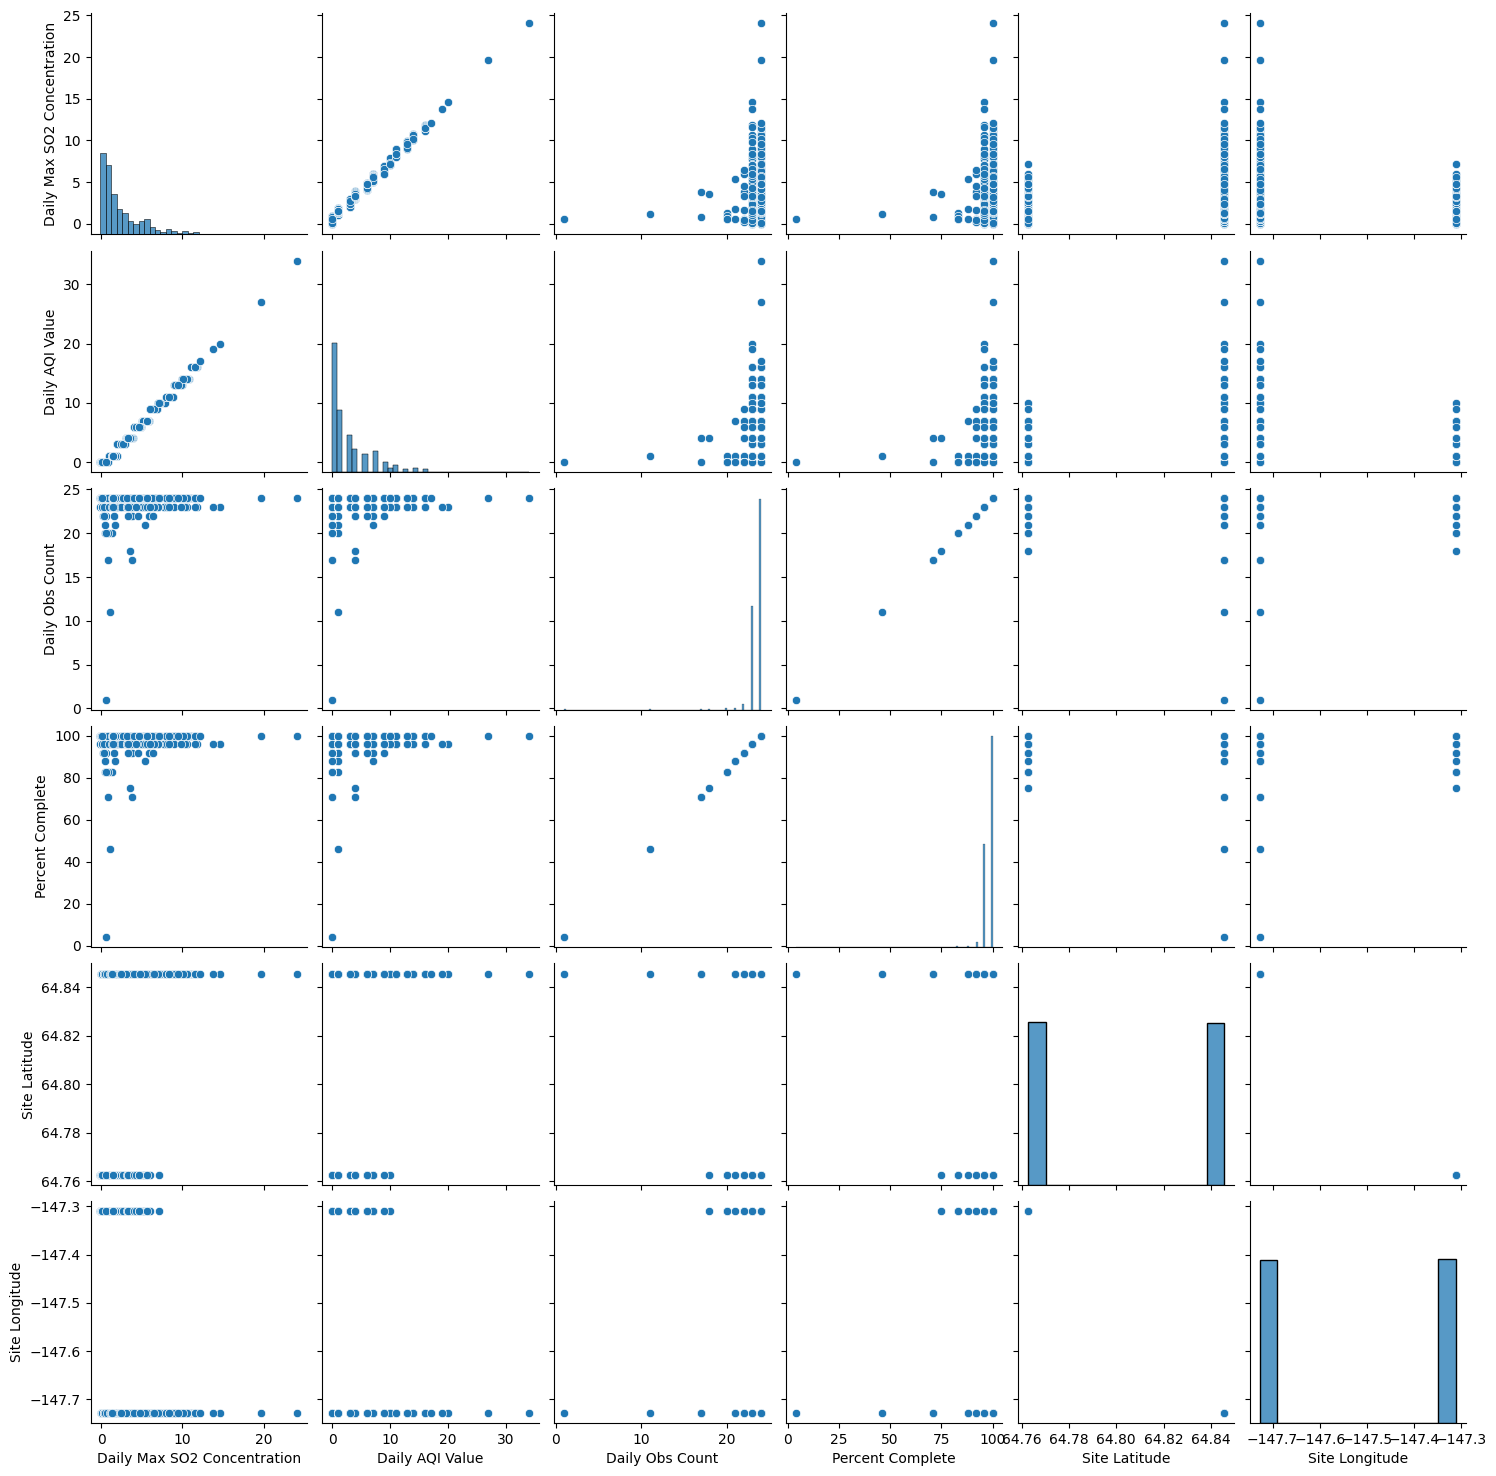

In [ ]:
sns.pairplot(df_reg)

<Axes: ylabel='Frequency'>

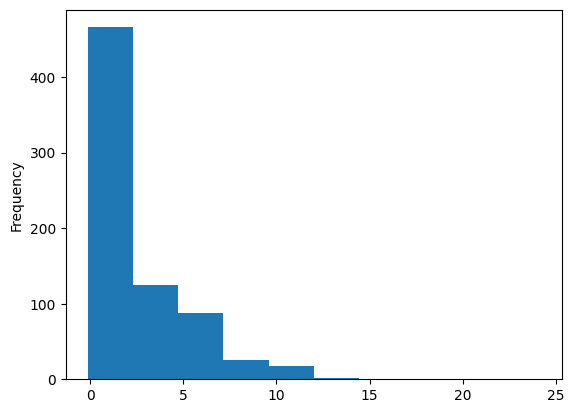

In [ ]:
df['Daily Max SO2 Concentration'].plot.hist()

<Axes: ylabel='Frequency'>

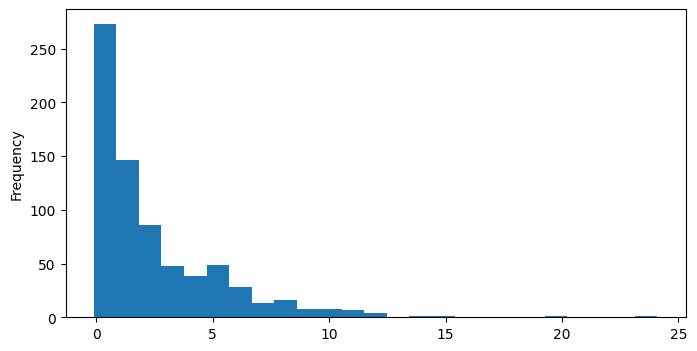

In [ ]:
df_reg['Daily Max SO2 Concentration'].plot.hist(bins=25, figsize=(8,4))

<Axes: ylabel='Density'>

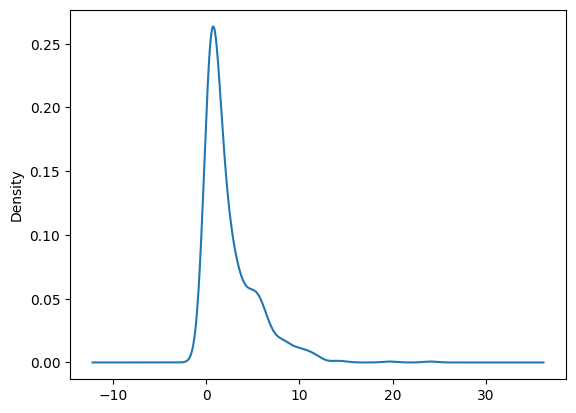

In [ ]:
df_reg['Daily Max SO2 Concentration'].plot.density()

In [ ]:
numeric_df = df_reg.select_dtypes(include=[np.number])

numeric_df.corr().round(4)

,Daily Max SO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,Site Latitude,Site Longitude
Daily Max SO2 Concentration,1.0000,0.9940,0.0427,0.0429,0.4783,-0.4783
Daily AQI Value,0.9940,1.0000,0.0463,0.0466,0.4678,-0.4678
Daily Obs Count,0.0427,0.0463,1.0000,0.9998,-0.0274,0.0274
Percent Complete,0.0429,0.0466,0.9998,1.0000,-0.0273,0.0273
Site Latitude,0.4783,0.4678,-0.0274,-0.0273,1.0000,-1.0000
Site Longitude,-0.4783,-0.4678,0.0274,0.0273,-1.0000,1.0000


<Axes: >

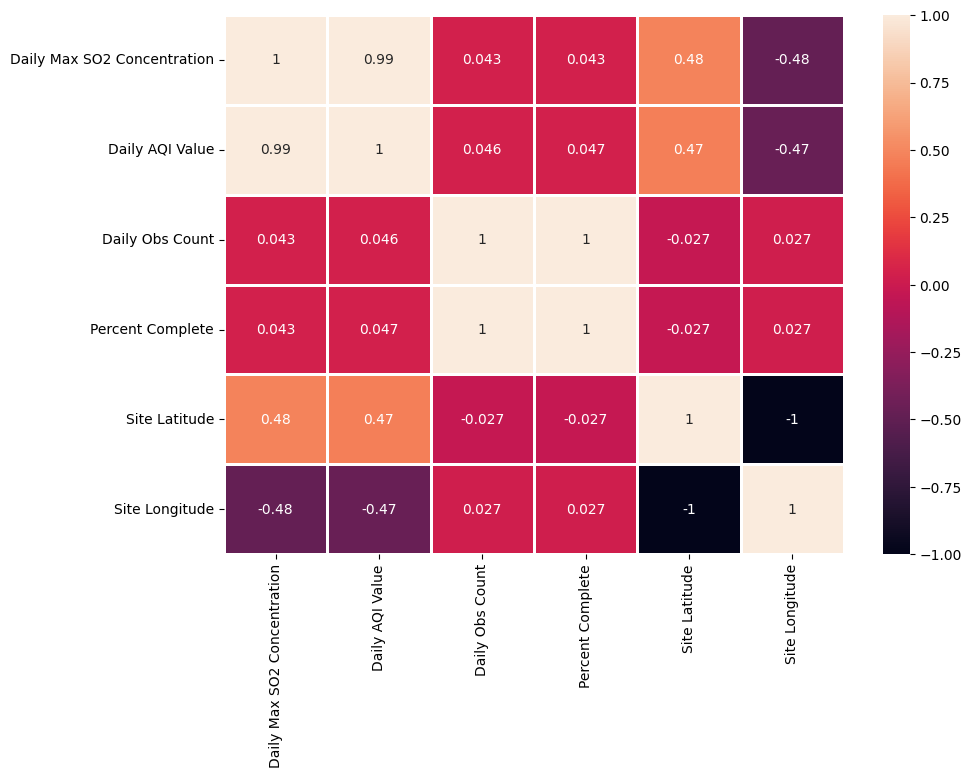

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, linewidths=2)

In [ ]:
l_column = list(df_reg.columns)
len_feature = len(l_column)
l_column

['Daily Max SO2 Concentration',
 'Daily AQI Value',
 'Daily Obs Count',
 'Percent Complete',
 'Site Latitude',
 'Site Longitude']

In [ ]:
x = df_reg[[
    'Daily AQI Value',
    'Daily Obs Count',
    'Percent Complete',
    'Site Latitude',
    'Site Longitude'
]]

y = df_reg['Daily Max SO2 Concentration']

x.head()

,Daily AQI Value,Daily Obs Count,Percent Complete,Site Latitude,Site Longitude
0,13,24,100,64.84569,-147.727413
1,14,24,100,64.84569,-147.727413
2,20,23,96,64.84569,-147.727413
3,16,24,100,64.84569,-147.727413
4,11,24,100,64.84569,-147.727413


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=124
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [ ]:
lm = LinearRegression()

In [ ]:
lm.fit(x_train, y_train)

LinearRegression()

In [ ]:
print("El término de intersección del modelo linear:", lm.intercept_)

El término de intersección del modelo linear: -27.25694245416251


In [ ]:
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [ 0.6862019   1.36577191 -0.33168898  0.03495017 -0.1755458 ]


In [ ]:
cdf = pd.DataFrame(
    data=lm.coef_,
    index=x_train.columns,
    columns=["Coefficients"]
)

cdf

,Coefficients
Daily AQI Value,0.686202
Daily Obs Count,1.365772
Percent Complete,-0.331689
Site Latitude,0.034950
Site Longitude,-0.175546


In [ ]:
predictions = lm.predict(x_test)

print("Tipo del objeto predicho:", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho: <class 'numpy.ndarray'>
Tamaño del objeto predicho: (219,)


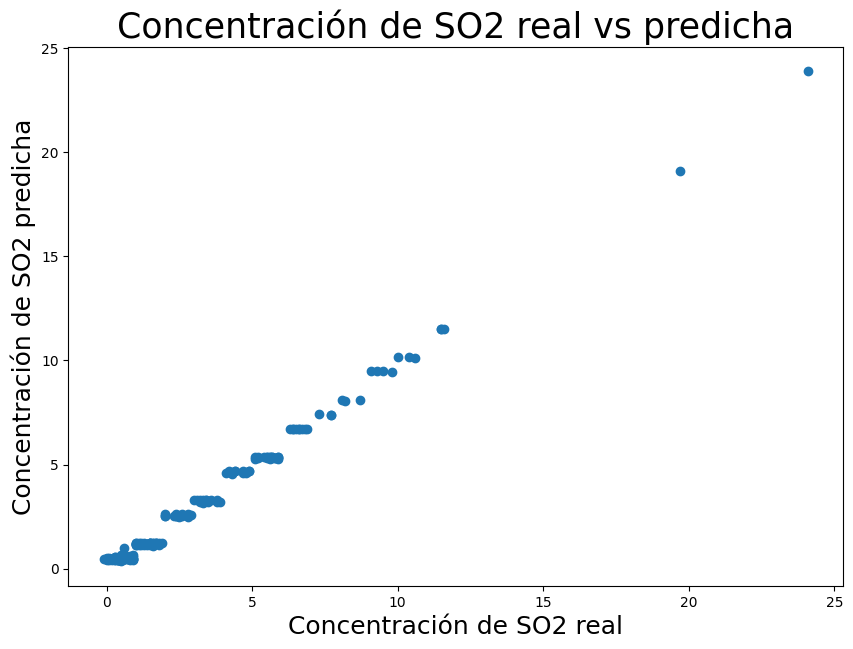

In [ ]:
plt.figure(figsize=(10,7))

plt.title("Concentración de SO2 real vs predicha", fontsize=25)
plt.xlabel("Concentración de SO2 real", fontsize=18)
plt.ylabel("Concentración de SO2 predicha", fontsize=18)

plt.scatter(x=y_test, y=predictions)

/tmp/ipykernel_1047/2176432368.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([y_test-predictions])


<Axes: title={'center': 'Histograma de residuos para verificar la normalidad'}, xlabel='Residuos', ylabel='Densidad del kernel'>

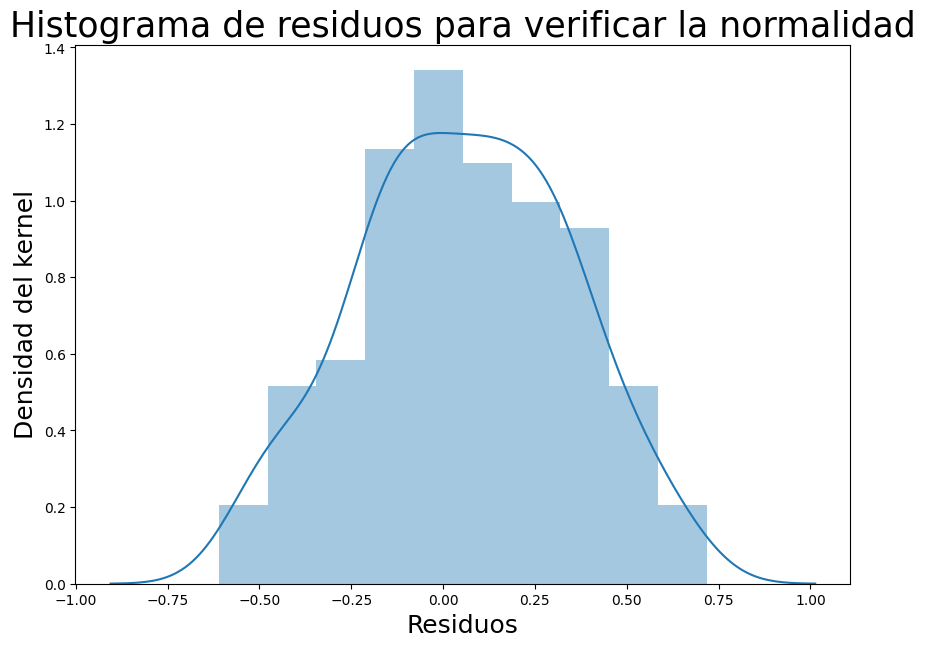

In [ ]:
plt.figure(figsize=(10,7))

plt.title(
    "Histograma de residuos para verificar la normalidad",
    fontsize=25
)

plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)

sns.distplot([y_test-predictions])

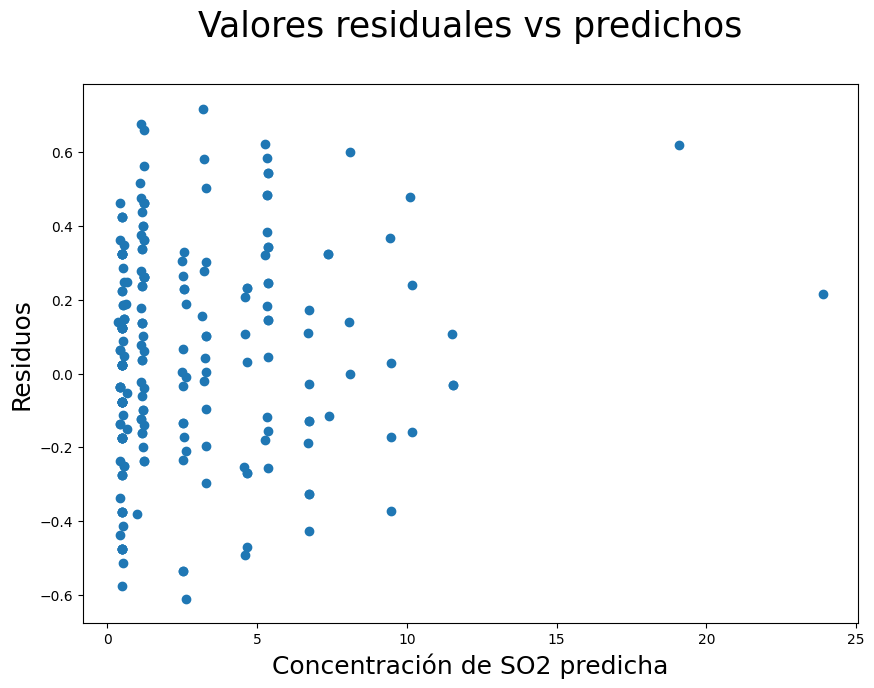

In [ ]:
plt.figure(figsize=(10,7))

plt.title("Valores residuales vs predichos\n", fontsize=25)
plt.xlabel("Concentración de SO2 predicha", fontsize=18)
plt.ylabel("Residuos", fontsize=18)

plt.scatter(
    x=predictions,
    y=y_test-predictions
)

In [ ]:
print(
    "Mean square error (MSE):",
    metrics.mean_squared_error(y_test, predictions)
)

Mean square error (MSE): 0.08602651914926443
